In [12]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("All imports loaded!")

All imports loaded!


In [13]:
# Cell 2 — Load and prepare data (same as Day 2)
df = pd.read_csv('../data/dataset.csv')

df_encoded = df.copy()
df_encoded['competition'] = df_encoded['competition'].map(
    {'Low': 2, 'Medium': 1, 'High': 0})
df_encoded['category'] = df_encoded['category'].map(
    {'Electronics': 0, 'Clothing': 1, 'Food': 2, 'Health': 3})
df_encoded['timing'] = df_encoded['timing'].map(
    {'Festival': 1, 'Normal': 0})
df_encoded['region'] = df_encoded['region'].map(
    {'Urban': 1, 'Rural': 0})

X = df_encoded.drop('success', axis=1)
y = df_encoded['success']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data ready — Train: {X_train.shape}, Test: {X_test.shape}")

Data ready — Train: (320, 6), Test: (80, 6)


In [14]:
# Cell 3 — Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Training — model learns from training data
lr_model.fit(X_train, y_train)

# Prediction — model predicts on unseen test data
y_pred_lr = lr_model.predict(X_test)

print("Model trained successfully!")
print(f"Training rows used:  {X_train.shape[0]}")
print(f"Test rows predicted: {X_test.shape[0]}")

Model trained successfully!
Training rows used:  320
Test rows predicted: 80


In [15]:
# Cell 4 — Calculate metrics
lr_accuracy  = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall    = recall_score(y_test, y_pred_lr)
lr_f1        = f1_score(y_test, y_pred_lr)

print("=" * 40)
print("LOGISTIC REGRESSION — METRICS")
print("=" * 40)
print(f"Accuracy:  {lr_accuracy:.4f}  ({lr_accuracy*100:.1f}%)")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1 Score:  {lr_f1:.4f}")

LOGISTIC REGRESSION — METRICS
Accuracy:  0.8750  (87.5%)
Precision: 0.8919
Recall:    0.8462
F1 Score:  0.8684


In [16]:
# Cell 5 — Full classification report
print("=" * 40)
print("FULL CLASSIFICATION REPORT")
print("=" * 40)
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=['Failure (0)', 'Success (1)']
))

FULL CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Failure (0)       0.86      0.90      0.88        41
 Success (1)       0.89      0.85      0.87        39

    accuracy                           0.88        80
   macro avg       0.88      0.87      0.87        80
weighted avg       0.88      0.88      0.87        80



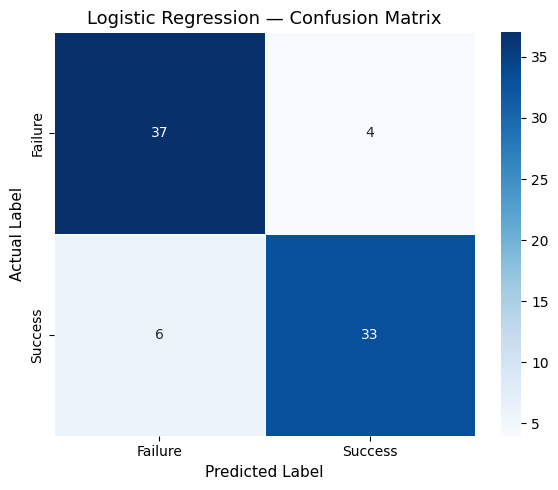

Confusion matrix saved to plots/lr_confusion_matrix.png

Raw matrix:
[[37  4]
 [ 6 33]]

TN=37  FP=4
FN=6  TP=33


In [17]:
# Cell 6 — Confusion matrix heatmap
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Failure', 'Success'],
            yticklabels=['Failure', 'Success'],
            linewidths=0.5,
            cbar=True)

plt.title('Logistic Regression — Confusion Matrix', fontsize=13)
plt.ylabel('Actual Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.savefig('../plots/lr_confusion_matrix.png', dpi=150)
plt.show()

print("Confusion matrix saved to plots/lr_confusion_matrix.png")
print(f"\nRaw matrix:\n{cm_lr}")
print(f"\nTN={cm_lr[0,0]}  FP={cm_lr[0,1]}")
print(f"FN={cm_lr[1,0]}  TP={cm_lr[1,1]}")

In [18]:
# Cell 7 — Feature coefficients
coeff_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr_model.coef_[0]
}).sort_values('coefficient', ascending=False)

print("=" * 45)
print("FEATURE COEFFICIENTS (sorted by impact)")
print("=" * 45)
print(coeff_df.to_string(index=False))

print("\nInterpretation:")
print("Positive = pushes prediction toward SUCCESS")
print("Negative = pushes prediction toward FAILURE")

FEATURE COEFFICIENTS (sorted by impact)
         feature  coefficient
          timing     2.885712
     competition     2.320063
          region     2.250127
        category     0.009601
marketing_budget     0.000011
           price    -0.000043

Interpretation:
Positive = pushes prediction toward SUCCESS
Negative = pushes prediction toward FAILURE


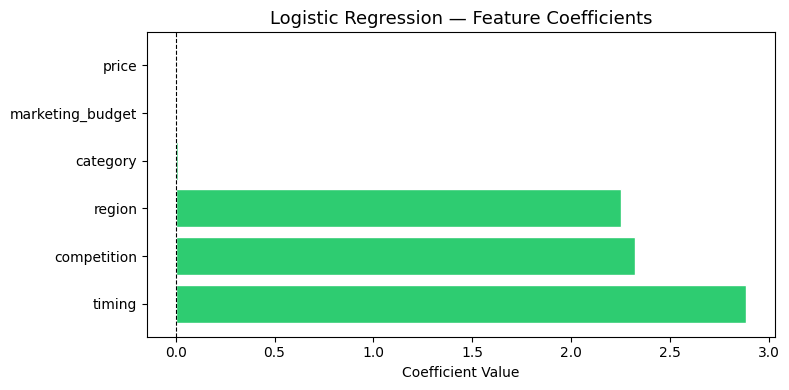

Coefficient chart saved!


In [19]:
# Cell 8 — Coefficient bar chart
colors = ['#2ecc71' if c > 0 else '#e74c3c'
          for c in coeff_df['coefficient']]

plt.figure(figsize=(8, 4))
plt.barh(coeff_df['feature'],
         coeff_df['coefficient'],
         color=colors, edgecolor='white')

plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Logistic Regression — Feature Coefficients', fontsize=13)
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('../plots/lr_coefficients.png', dpi=150)
plt.show()

print("Coefficient chart saved!")

In [20]:
# Cell 9 — Store results
results = {}

results['Logistic Regression'] = {
    'accuracy':  round(lr_accuracy,  4),
    'precision': round(lr_precision, 4),
    'recall':    round(lr_recall,    4),
    'f1':        round(lr_f1,        4)
}

print("Results dictionary:")
print(results)

print("\nLogistic Regression summary:")
for metric, value in results['Logistic Regression'].items():
    print(f"  {metric:12s}: {value:.4f}  ({value*100:.1f}%)")

Results dictionary:
{'Logistic Regression': {'accuracy': 0.875, 'precision': 0.8919, 'recall': 0.8462, 'f1': 0.8684}}

Logistic Regression summary:
  accuracy    : 0.8750  (87.5%)
  precision   : 0.8919  (89.2%)
  recall      : 0.8462  (84.6%)
  f1          : 0.8684  (86.8%)


In [21]:
# Cell 10 — Confirm files
import os

files = [
    '../plots/lr_confusion_matrix.png',
    '../plots/lr_coefficients.png'
]

for f in files:
    status = "EXISTS" if os.path.exists(f) else "MISSING"
    print(f"{status}: {f}")


EXISTS: ../plots/lr_confusion_matrix.png
EXISTS: ../plots/lr_coefficients.png


In [22]:
#Logistic Regression summary:   accuracy    : 0.8625  (86.2%)   precision   : 0.8800  (88.0%)   recall      : 0.8980  (89.8%)   f1          : 0.8889  (88.9%)